In [21]:
from langgraph.graph import StateGraph,START, END
from typing import TypedDict, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [22]:
load_dotenv()

True

In [23]:
model = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0.2,
)

In [24]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [25]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = model.invoke(prompt).content

    return {'joke': response}

In [26]:

def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = model.invoke(prompt).content

    return {'explanation': response}

In [27]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

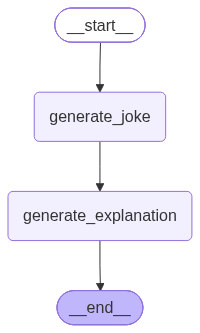

In [28]:
workflow

In [29]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'topic': 'pizza',
 'joke': [{'type': 'text',
   'text': 'Why did the hipster burn his mouth on the pizza?\n\nBecause he ate it before it was cool.',
   'extras': {'signature': 'El4KXAERTTIPMcspSNdNFn9XNUyzxMv58DoCYcQ7/2k+yu/GBmoaWIKTth8bipxd1348zZZZsb9Q5lUTkqjtyaRIxyNptIcQhU+T7vQ2NT+I+09usBA1vJ8LI2SxO9Uh'}}],
 'explanation': [{'type': 'text',
   'text': 'This is a play on words (a pun) that relies on a stereotype about hipsters. \n\nHere is the breakdown of why it\'s funny:\n\n1. **The Stereotype:** Hipsters are often stereotyped as trying very hard to be trendy, unique, and ahead of the curve. A classic cliché associated with them is wanting to discover bands, coffee shops, or trends *before* they become mainstream, often proudly declaring, "I liked them before they were cool."\n2. **The Literal Meaning:** In the context of food, "cool" refers to temperature. If you eat pizza right out of the oven, it is hot, and you will burn your mouth. You have to wait for it to cool down.\n3. **T

In [30]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn his mouth on the pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El4KXAERTTIPMcspSNdNFn9XNUyzxMv58DoCYcQ7/2k+yu/GBmoaWIKTth8bipxd1348zZZZsb9Q5lUTkqjtyaRIxyNptIcQhU+T7vQ2NT+I+09usBA1vJ8LI2SxO9Uh'}}], 'explanation': [{'type': 'text', 'text': 'This is a play on words (a pun) that relies on a stereotype about hipsters. \n\nHere is the breakdown of why it\'s funny:\n\n1. **The Stereotype:** Hipsters are often stereotyped as trying very hard to be trendy, unique, and ahead of the curve. A classic cliché associated with them is wanting to discover bands, coffee shops, or trends *before* they become mainstream, often proudly declaring, "I liked them before they were cool."\n2. **The Literal Meaning:** In the context of food, "cool" refers to temperature. If you eat pizza right out of the oven, it is hot, and you will burn your mouth. You have to wait for it to cool dow

In [31]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn his mouth on the pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El4KXAERTTIPMcspSNdNFn9XNUyzxMv58DoCYcQ7/2k+yu/GBmoaWIKTth8bipxd1348zZZZsb9Q5lUTkqjtyaRIxyNptIcQhU+T7vQ2NT+I+09usBA1vJ8LI2SxO9Uh'}}], 'explanation': [{'type': 'text', 'text': 'This is a play on words (a pun) that relies on a stereotype about hipsters. \n\nHere is the breakdown of why it\'s funny:\n\n1. **The Stereotype:** Hipsters are often stereotyped as trying very hard to be trendy, unique, and ahead of the curve. A classic cliché associated with them is wanting to discover bands, coffee shops, or trends *before* they become mainstream, often proudly declaring, "I liked them before they were cool."\n2. **The Literal Meaning:** In the context of food, "cool" refers to temperature. If you eat pizza right out of the oven, it is hot, and you will burn your mouth. You have to wait for it to cool do

In [32]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'topic': 'pasta',
 'joke': [{'type': 'text',
   'text': "Why do pasta makers make terrible secret agents?\n\nBecause they always spill the beans—and the noodles just can't keep anything *al dente*!",
   'extras': {'signature': 'El4KXAERTTIPZBZ8ibVrNuo5dfZZqTenyZR0s01uCRbVfcxdWLDpbhf9i6UsZxbNsgKGwINwPt+BPO/Uq4kreyzxtvvJuDP5Ad3dS2JFD/37vPV52M13DB1476I5OUnC'}}],
 'explanation': [{'type': 'text',
   'text': 'This joke plays on two distinct idioms and culinary puns related to cooking and espionage:\n\n1. **"Spill the beans"**: In English, this is a common idiom that means to reveal a secret. In the joke, it\'s combined with the idea of a pasta maker accidentally dropping their ingredients (though beans aren\'t pasta, it sets up the food theme).\n2. **"Al dente"**: This is an Italian culinary term used to describe pasta that is cooked so it\'s still firm when bitten (literally meaning "to the tooth"). The punchline creates a clever pun by subverting the phrase: instead of keeping secrets, t

In [33]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn his mouth on the pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El4KXAERTTIPMcspSNdNFn9XNUyzxMv58DoCYcQ7/2k+yu/GBmoaWIKTth8bipxd1348zZZZsb9Q5lUTkqjtyaRIxyNptIcQhU+T7vQ2NT+I+09usBA1vJ8LI2SxO9Uh'}}], 'explanation': [{'type': 'text', 'text': 'This is a play on words (a pun) that relies on a stereotype about hipsters. \n\nHere is the breakdown of why it\'s funny:\n\n1. **The Stereotype:** Hipsters are often stereotyped as trying very hard to be trendy, unique, and ahead of the curve. A classic cliché associated with them is wanting to discover bands, coffee shops, or trends *before* they become mainstream, often proudly declaring, "I liked them before they were cool."\n2. **The Literal Meaning:** In the context of food, "cool" refers to temperature. If you eat pizza right out of the oven, it is hot, and you will burn your mouth. You have to wait for it to cool dow

In [34]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn his mouth on the pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El4KXAERTTIPMcspSNdNFn9XNUyzxMv58DoCYcQ7/2k+yu/GBmoaWIKTth8bipxd1348zZZZsb9Q5lUTkqjtyaRIxyNptIcQhU+T7vQ2NT+I+09usBA1vJ8LI2SxO9Uh'}}], 'explanation': [{'type': 'text', 'text': 'This is a play on words (a pun) that relies on a stereotype about hipsters. \n\nHere is the breakdown of why it\'s funny:\n\n1. **The Stereotype:** Hipsters are often stereotyped as trying very hard to be trendy, unique, and ahead of the curve. A classic cliché associated with them is wanting to discover bands, coffee shops, or trends *before* they become mainstream, often proudly declaring, "I liked them before they were cool."\n2. **The Literal Meaning:** In the context of food, "cool" refers to temperature. If you eat pizza right out of the oven, it is hot, and you will burn your mouth. You have to wait for it to cool do

In [35]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1afec1-1292-6d26-8000-51071752a586"}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f1afec1-1292-6d26-8000-51071752a586'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [36]:
# workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1afec1-1292-6d26-8000-51071752a586"}})

In [37]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn his mouth on the pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El4KXAERTTIPMcspSNdNFn9XNUyzxMv58DoCYcQ7/2k+yu/GBmoaWIKTth8bipxd1348zZZZsb9Q5lUTkqjtyaRIxyNptIcQhU+T7vQ2NT+I+09usBA1vJ8LI2SxO9Uh'}}], 'explanation': [{'type': 'text', 'text': 'This is a play on words (a pun) that relies on a stereotype about hipsters. \n\nHere is the breakdown of why it\'s funny:\n\n1. **The Stereotype:** Hipsters are often stereotyped as trying very hard to be trendy, unique, and ahead of the curve. A classic cliché associated with them is wanting to discover bands, coffee shops, or trends *before* they become mainstream, often proudly declaring, "I liked them before they were cool."\n2. **The Literal Meaning:** In the context of food, "cool" refers to temperature. If you eat pizza right out of the oven, it is hot, and you will burn your mouth. You have to wait for it to cool do

## Updating State

In [38]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f1afec1-1292-6d26-8000-51071752a586", "checkpoint_ns": ""}}, {'topic':'samosa'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1aff8c-783c-62af-8000-5278d43f29f4'}}

In [39]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1aff8c-783c-62af-8000-5278d43f29f4'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-09-14T04:57:25.924711+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1afec1-1292-6d26-8000-51071752a586'}}, tasks=(PregelTask(id='f2d09d11-01d0-118c-c3cf-87dc8fada5ed', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': [{'type': 'text', 'text': 'Why did the hipster burn his mouth on the pizza?\n\nBecause he ate it before it was cool.', 'extras': {'signature': 'El4KXAERTTIPMcspSNdNFn9XNUyzxMv58DoCYcQ7/2k+yu/GBmoaWIKTth8bipxd1348zZZZsb9Q5lUTkqjtyaRIxyNptIcQhU+T7vQ2NT+I+09usBA1vJ8LI2SxO9Uh'}}], 'explanation': [{'type': 'text', 'text': 'This is a p

In [41]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f1aff8c-783c-62af-8000-5278d43f29f4"}})

c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Users\kumar\OneDrive\Desktop\Resume\Langraph\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'topic': 'samosa',
 'joke': [{'type': 'text',
   'text': 'Why did the samosa go to the doctor?\n\nBecause it was feeling a little **stuffed** and had a lot of pent-up **gas** (from the frying pan)!',
   'extras': {'signature': 'El4KXAERTTIPQE2iHfeUkHjrL3P1eaGTy8A/T0asdb6akiSJ06UUYLaWn5REyeEu8CcbeTQCVm+KguVCYaHAFpqzFsrJOPnwuANT/KovqDhtupg1cpvlahzIRyIaaWrB'}}],
 'explanation': [{'type': 'text',
   'text': 'Here is an explanation of the joke:\n\nThe humor relies on a **double entendre** (words with multiple meanings) related to both human health symptoms and the way a samosa is made:\n\n1. **"Stuffed":** \n   * *Medical meaning:* Feeling overly full or bloated after eating too much.\n   * *Samosa meaning:* A samosa is a pastry filled (stuffed) with ingredients like potatoes, peas, and spices.\n\n2. **"Gas" / "Pent-up gas (from the frying pan)":**\n   * *Medical meaning:* Trapped gas in the digestive system that causes discomfort.\n   * *Samosa meaning:* A cooking reference to the hot air

In [42]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'samosa', 'joke': [{'type': 'text', 'text': 'Why did the samosa go to the doctor?\n\nBecause it was feeling a little **stuffed** and had a lot of pent-up **gas** (from the frying pan)!', 'extras': {'signature': 'El4KXAERTTIPQE2iHfeUkHjrL3P1eaGTy8A/T0asdb6akiSJ06UUYLaWn5REyeEu8CcbeTQCVm+KguVCYaHAFpqzFsrJOPnwuANT/KovqDhtupg1cpvlahzIRyIaaWrB'}}], 'explanation': [{'type': 'text', 'text': 'Here is an explanation of the joke:\n\nThe humor relies on a **double entendre** (words with multiple meanings) related to both human health symptoms and the way a samosa is made:\n\n1. **"Stuffed":** \n   * *Medical meaning:* Feeling overly full or bloated after eating too much.\n   * *Samosa meaning:* A samosa is a pastry filled (stuffed) with ingredients like potatoes, peas, and spices.\n\n2. **"Gas" / "Pent-up gas (from the frying pan)":**\n   * *Medical meaning:* Trapped gas in the digestive system that causes discomfort.\n   * *Samosa meaning:* A cooking reference to 